In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import decorate, configure_plot_style, AIBM_COLORS

configure_plot_style()

## Read the data

In [3]:
!ls *min*.csv

wef_ministerial_positions.csv  wef_ministerial_table.csv


In [4]:
xlabel = 'Women in Ministerial Positions'

In [5]:

import os
from extract_pdf_data import read_pdfs

filename = "wef_ministerial_positions.csv"
if not os.path.exists(filename):
    df = read_pdfs('legislators')
    df.to_csv(filename, index=False)

In [6]:
from utils import read_wef_file

df = read_wef_file(filename)
df.head()

,country,page_number,score,rank,diff,left,right
code,,,,,,,
ALB,Albania,83,1.000,1,0.00,50.00,50.00
DZA,Algeria,85,0.167,107,-71.43,14.29,85.71
AGO,Angola,87,0.643,26,-21.74,39.13,60.87
ARG,Argentina,89,0.500,36,-33.33,33.33,66.67
ARM,Armenia,91,0.200,98,-66.67,16.67,83.33


In [7]:
df['rank'].value_counts(dropna=False).head()

rank
1      13
36      8
65      7
116     6
52      4
Name: count, dtype: int64

In [8]:
df['score'].describe()

count    146.000000
mean       0.376404
std        0.284567
min        0.000000
25%        0.167000
50%        0.310500
75%        0.500000
max        1.000000
Name: score, dtype: float64

In [9]:
dinged = df['score'] < 1
dinged.sum()

133

Here is the distribution of their scores.

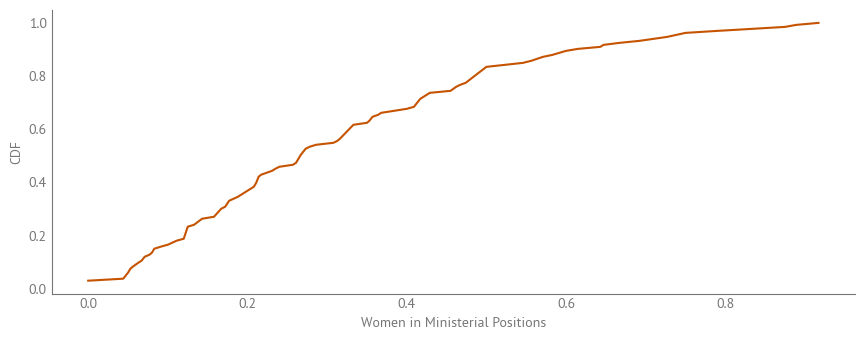

In [10]:
from empiricaldist import Cdf

cdf_score = Cdf.from_seq(df.loc[dinged, 'score'])
cdf_score.plot()
decorate(xlabel=xlabel, ylabel='CDF')

In [11]:
subset = df[dinged]
subset.sort_values("diff", ascending=False)

,country,page_number,score,rank,diff,left,right
code,,,,,,,
SWE,Sweden,335,0.917,14,-4.35,47.83,52.17
FRA,France,181,0.889,15,-5.88,47.06,52.94
DEU,Germany,187,0.875,16,-6.67,46.67,53.33
AUS,Australia,93,0.833,17,-9.09,45.45,54.55
CAN,Canada,135,0.790,18,-11.76,44.12,55.88
...,...,...,...,...,...,...,...
CHN,China,143,0.044,142,-91.67,4.17,95.83
HUN,Hungary,201,0.000,143,-100.00,0.00,100.00
AZE,Azerbaijan,97,0.000,143,-100.00,0.00,100.00


## Revised scores

The scores are based on ratios, not differences, so let's compute those.

In [12]:
df['ratio'] = df['left'] / df['right']
df['ratio'].describe()

count    146.000000
mean       0.366520
std        0.267652
min        0.000000
25%        0.166725
50%        0.310105
75%        0.499925
max        1.000000
Name: ratio, dtype: float64

Looks like the ratio IS the score.

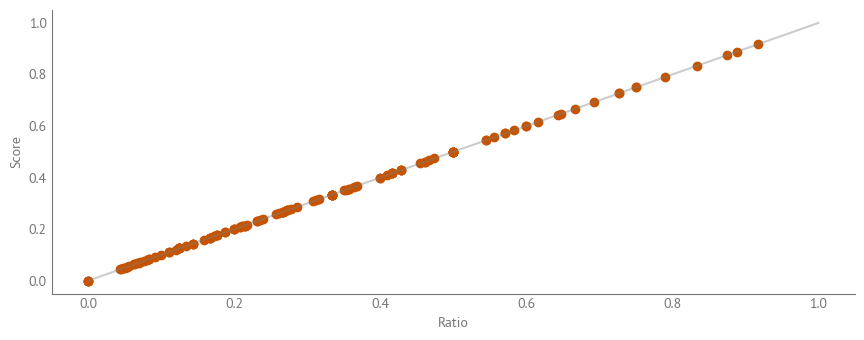

In [13]:
subset = df[dinged]
plt.plot([0, 1], [0, 1], color='gray', alpha=0.4)
plt.scatter(subset['ratio'], subset['score'])
decorate(xlabel='Ratio', ylabel='Score')

So here are the revised, symmetric scores.

In [14]:
df['revised_score'] = df['ratio']
df['revised_score'].describe()

count    146.000000
mean       0.366520
std        0.267652
min        0.000000
25%        0.166725
50%        0.310105
75%        0.499925
max        1.000000
Name: revised_score, dtype: float64

Here's the distribution of revised scores.

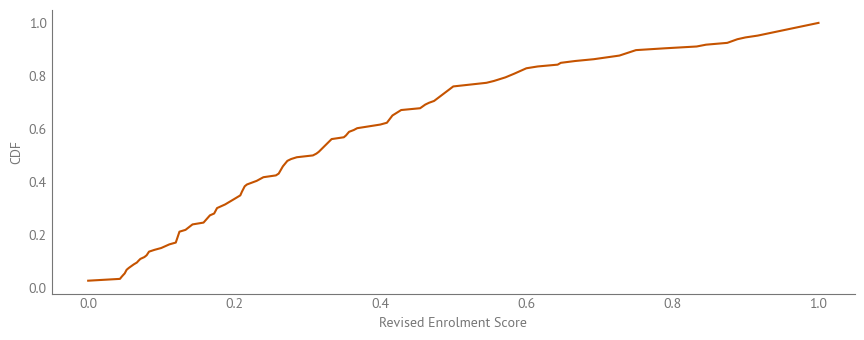

In [15]:
cdf_score = Cdf.from_seq(df['revised_score'])
cdf_score.plot()
decorate(xlabel='Revised Enrolment Score', ylabel='CDF')

Here's the distribution of revised scores, compare to the original.

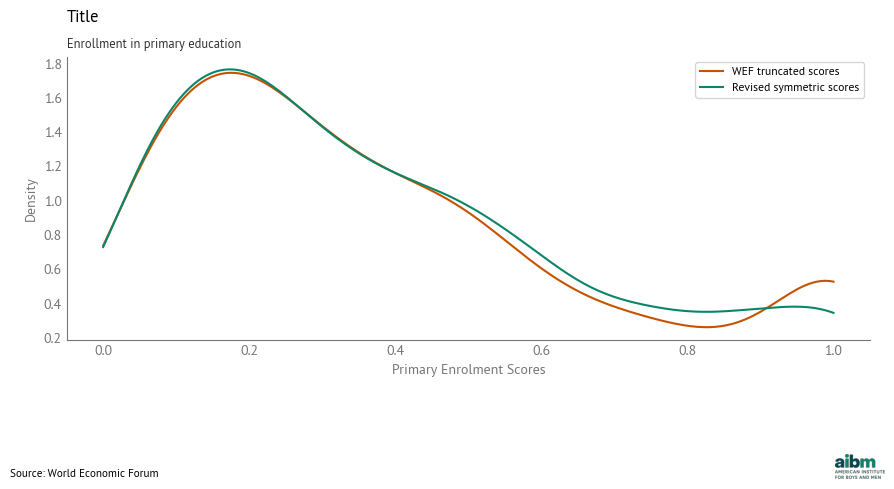

In [16]:
from utils import plot_score_distributions, add_title

plot_score_distributions(df, xlabel='Primary Enrolment Scores')
add_title("Title",
          "Enrollment in primary education")

In [17]:
revised = df[~dinged].dropna(subset=['ratio']).sort_values('revised_score')
revised.shape

(13, 9)

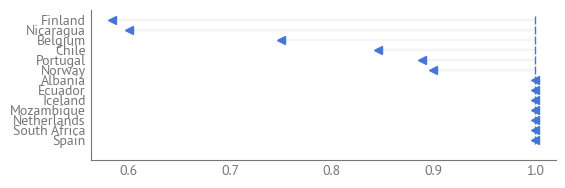

In [18]:
from utils import plot_revised_scores

plot_revised_scores(revised)

## Export the results

In [19]:
from utils import make_rank_table

table = make_rank_table(df)
table.to_csv("wef_ministerial_table.csv")
table.shape

(146, 6)

In [20]:
table['score'].describe()

count    146.000000
mean       0.376404
std        0.284567
min        0.000000
25%        0.167000
50%        0.310500
75%        0.500000
max        1.000000
Name: score, dtype: float64

In [21]:
from utils import make_weight_table

make_weight_table(table, 'ministerial_positions')

original             revised          
                            std   inv std       std   inv std
ministerial_positions  0.284567  0.035141  0.267652  0.037362

## OECD countries

In [22]:
from utils import oecd_codes

df_oecd = df.loc[oecd_codes].sort_values(by='revised_score')

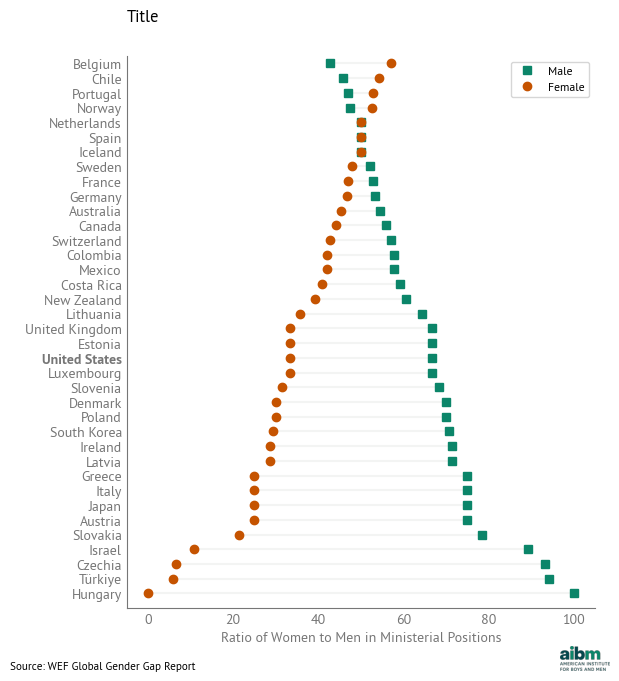

In [23]:
from utils import plot_percentages

plot_percentages(df_oecd)
plt.xlabel('Ratio of Women to Men in Ministerial Positions')
add_title("Title",
          " ", y=1.01)


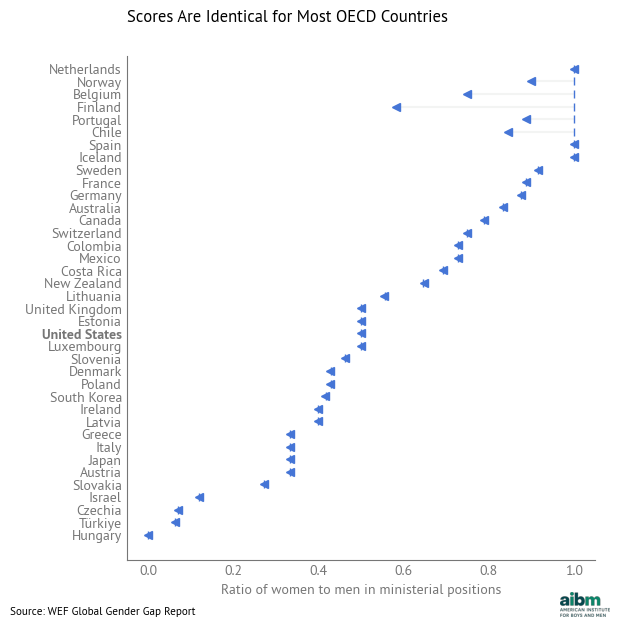

In [24]:
from utils import plot_revised_scores
from utils import add_title, add_subtext, add_logo

plot_revised_scores(df_oecd.sort_values(by='score', ascending=False))
decorate(xlabel='Ratio of women to men in ministerial positions')
add_title('Scores Are Identical for Most OECD Countries',
          '', y=1.02)
add_subtext('Source: WEF Global Gender Gap Report', y=-0.01)
logo = add_logo(location=(1.0, -0.01))

In [25]:
df.query("country == 'Ireland'")

,country,page_number,score,rank,diff,left,right,ratio,revised_score,revised_rank
code,,,,,,,,,,
IRL,Ireland,211,0.4,57,-42.86,28.57,71.43,0.399972,0.399972,57.0
